# Introduction: The Geometric Intuition"
"Stop thinking in formulas, start thinking in flows."

In traditional calculus, we are taught to solve $\dot{x} = f(x)$ by integrating to find $x(t)$. But for most complex systems, an analytical solution is impossible. Steven Strogatz argues that we should instead look at the Vector Field.

"We think of $t$ as time, $x$ as the position of an imaginary particle moving along the real line, and $\dot{x}$ as the velocity of that particle... The flow is to the right where $f(x) > 0$ and to the left where $f(x) < 0$." — Strogatz 

Fixed Points: The Anchors of Logic
- Attractors (Stable): Points where the flow converges. These represent "memories" or "steady states."
- Repellers (Unstable): Points where the flow pushes the state away. These represent "decision boundaries."

 # The Anatomy of Stability

## What is Stability?
In a dynamical system, a fixed point $x^*$ is stable if the system resists change. If you "nudge" the state slightly away from $x^*$, the physics of the system should force it back.

## Method 1: The Graphical Intuition (The "Velocity" View)
In 1D, $\dot{x} = f(x)$ means the graph of f(x) is a Velocity Map.

**The Nudge:** Imagine a fixed point at $x^*$.
- **Nudge Right ( x > $x^*$): If the graph of f(x) is below the x-axis (negative velocity), the particle is pushed back to the Left toward $x^*$.
- **Nudge Left ( x < $x^*$): If the graph of f(x) is above the x-axis (positive velocity), the particle is pushed back to the Right toward $x^*$.

**The Condition:** 
For the arrows to point "inward" from both sides, the function (x) must cross the x-axis from positive to negative. This is why a negative slope at the fixed point f(x^*) < 0 guarantees stability.

## Method 2: Linear Stability Analysis (The "Eigenvalue" View)
Let (t) = x(t) - $x^*$ be a tiny perturbation. As we derived in our derivations.md:

$$
\dot{u} \approx f'(x^*)u
$$
The solution is $u(t) = u(0)e^{f'(x^*)t}$.
In 1D, the Jacobian Matrix is just the scalar $J = [f'(x^*)]$.
The Eigenvalue $\lambda$ of this Jacobian is simply $f'(x^*)$.The Math of Decay: If $\lambda < 0$, the term $e^{\lambda t}$ represents exponential decay. The "error" $u(t)$ vanishes over time.


# Case Study: The Logistic Equation
 
## The Model
 
The Logistic Equation is defined as:
 
$$\dot{x} = rx \left(1 - \frac{x}{K}\right)$$
 
Setting growth rate $r = 1$ and carrying capacity $K = 1$, we get the simplified form:
 
$$\dot{x} = x(1 - x)$$
 
---
 
## Linear Stability Analysis
 
A small perturbation $u$ away from a fixed point $x^*$ evolves according to:
 
$$\dot{u} = f'(x^*)\, u$$
 
For $x^* = 1$: $\quad f'(1) = -1$
 
Since the slope is **negative**, the perturbation decays. **Prediction: $x = 1$ is a stable attractor.**
 
---
 
## Manual Implementation: The Euler Engine
 
The Euler method is the simplest way to simulate time — take the current position, calculate the velocity, and move a small step in that direction.
 
$$x_{n+1} = x_n + f(x_n)\,\Delta t$$

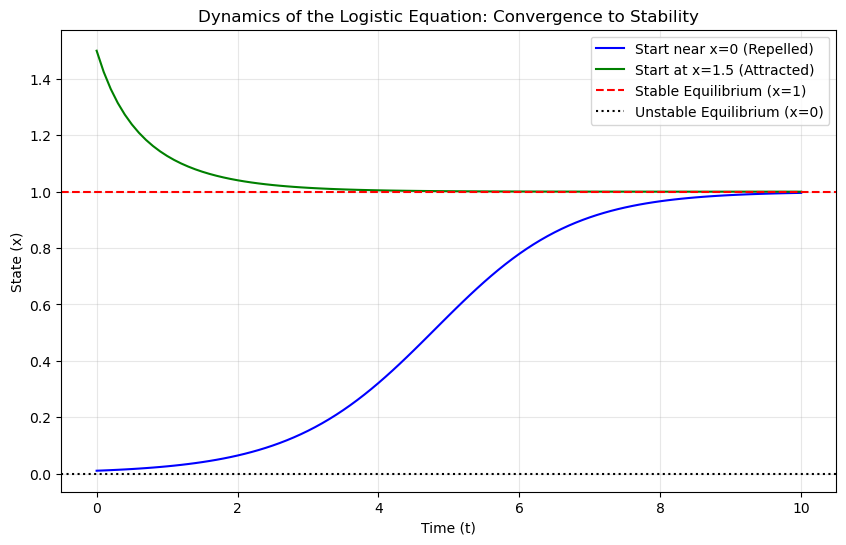

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_flow(x):
    """The velocity function f(x) = x(1 - x)"""
    return x * (1 - x)

def euler_solve(flow_func, x0, dt, total_time):
    # Calculate total number of steps
    steps = int(total_time / dt)
    
    # Initialize history with the starting point
    x_history = [x0]
    current_x = x0
    
    for i in range(steps):
        # 1. Calculate the velocity (v) at the current_x
        v = flow_func(current_x)
        
        # 2. Update current_x: new_x = old_x + velocity * dt
        current_x = current_x + v * dt
        
        # 3. Append the new state to our history
        x_history.append(current_x)
        
    return np.array(x_history)

# --- Simulation and Visualization ---
x0_unstable = 0.01  # Start near the unstable point x=0
x0_above = 1.5      # Start above the stable point x=1

dt = 0.1
T = 10

traj1 = euler_solve(logistic_flow, x0_unstable, dt, T)
traj2 = euler_solve(logistic_flow, x0_above, dt, T)

# Plotting the "Convergence to Stability"
plt.figure(figsize=(10, 6))
t_axis = np.linspace(0, T, len(traj1))

plt.plot(t_axis, traj1, label="Start near x=0 (Repelled)", color='blue')
plt.plot(t_axis, traj2, label="Start at x=1.5 (Attracted)", color='green')
plt.axhline(1, color='red', linestyle='--', label="Stable Equilibrium (x=1)")
plt.axhline(0, color='black', linestyle=':', label="Unstable Equilibrium (x=0)")

plt.title("Dynamics of the Logistic Equation: Convergence to Stability")
plt.xlabel("Time (t)")
plt.ylabel("State (x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# The Potential Perspective

Another way to visualize the dynamics of a first-order system $\dot{x} = f(x)$ is through **Potential Energy**.

We define a potential $V(x)$ such that:

$$f(x) = -\frac{dV}{dx}$$

Velocity is the **negative gradient** of Potential. The negative sign follows the standard convention in physics: the particle always moves **downhill** as the motion proceeds.

**Imagine** that the particle is heavily damped — its inertia is completely negligible compared to the damping force. For example, suppose the particle has to slog through a thick layer of goo. This is called an **overdamped** or **gradient-flow** system.
![From Nonlinear_Dynamics_and_Chaos_3rd_Ed_-_Steven_H_Strogatz](<attachment:Screenshot 2026-03-14 212626.png>)
- From Nonlinear_Dynamics_and_Chaos_3rd_Ed_-_Steven_H_Strogatz

In such a system:
- **Stable fixed points** = **valleys** (local minima of $V$). The particle slides in and stays.
- **Unstable fixed points** = **hilltops or saddle points** (local maxima of $V$). Any nudge sends the particle rolling away.
- **The particle can never go uphill** — energy always decreases monotonically.

---

## Bridge to Deep Learning: The Loss Landscape IS a Potential Well

This is not just analogy — it is a **mathematical identity**. Gradient Descent in neural network training is **exactly** the particle-in-goo system:

| Dynamical Systems | Deep Learning |
|---|---|
| State $x$ | Network parameters $\theta$ |
| Potential $V(x)$ | Loss function $\mathcal{L}(\theta)$ |
| Velocity $\dot{x} = -dV/dx$ | Gradient step $\dot{\theta} = -\nabla_{\theta}\mathcal{L}$ |
| Stable fixed point (valley) | Converged solution (learned minimum) |
| Unstable fixed point (hilltop) | Saddle point / bad local minimum |
| Energy always decreasing | Loss always decreasing (under well-behaved LR) |

### The Energy Principle: Physics ↔ AI

In **conservative physics** (a pendulum in vacuum), total energy $E = \text{KE} + \text{PE}$ is **constant**. The system orbits forever.

In **dissipative physics** (a pendulum in honey), energy is **continuously lost** to friction. The system settles to the nearest minimum.

Gradient descent is **dissipative**: every step strictly reduces the loss (for a small enough learning rate). This is why it converges instead of oscillating forever.

$$\frac{d\mathcal{L}}{dt} = \nabla_{\theta}\mathcal{L} \cdot \dot{\theta} = \nabla_{\theta}\mathcal{L} \cdot (-\nabla_{\theta}\mathcal{L}) = -\|\nabla_{\theta}\mathcal{L}\|^2 \leq 0$$

The loss **never increases** along a gradient-flow trajectory — exactly like a particle sliding downhill in goo. This is the **Lyapunov stability argument** that guarantees convergence in convex settings and guides intuition in non-convex ones.

> **Why this matters:** Modern physics (especially statistical mechanics and thermodynamics) studies how systems lose energy and settle into stable states. Deep learning training is formally the same mathematics. The "physics" of AI is the physics of overdamped gradient flow in a high-dimensional potential landscape. This is the intellectual bridge between the two fields.
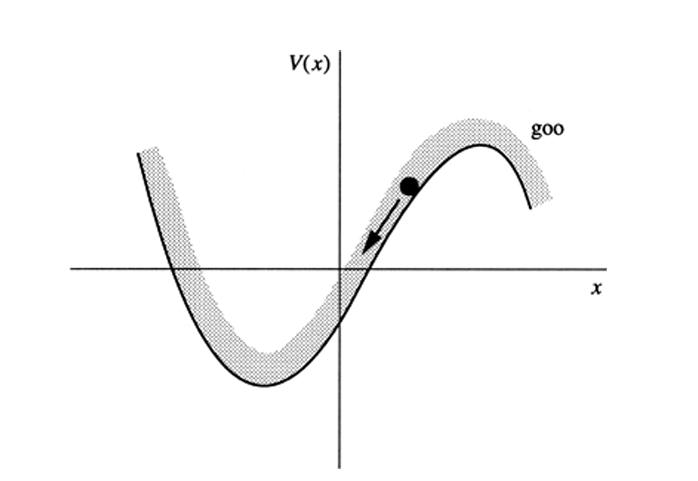

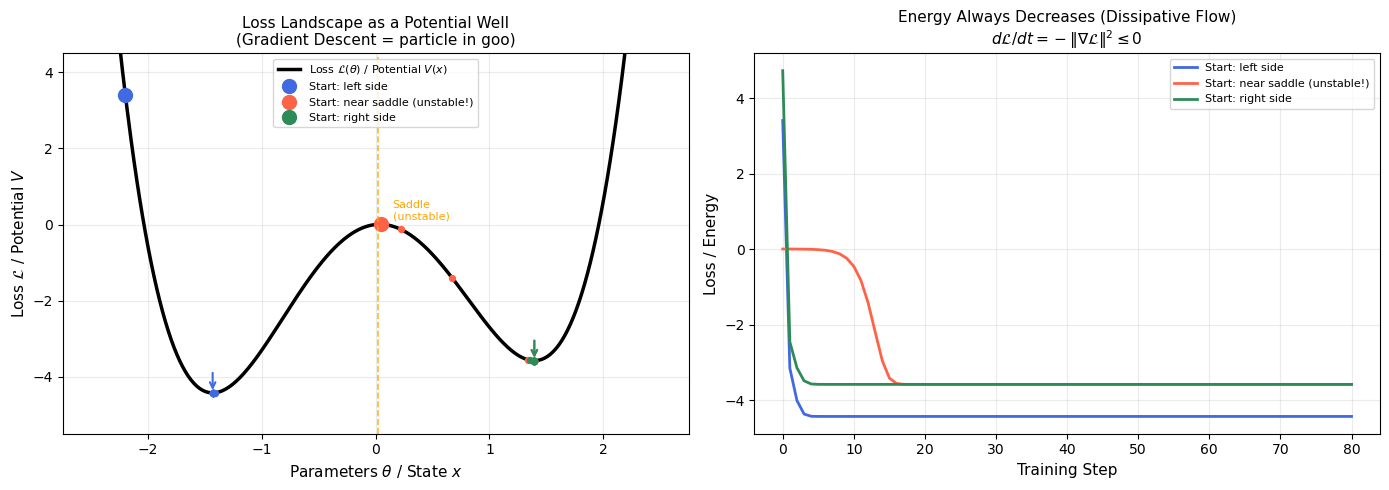


Key observations:
  • LEFT PLOT : every trajectory slides *downhill* — no uphill moves are possible.
  • The start near the saddle is unstable: tiny perturbation → rolls into a valley.
  • Different starts → different minima  (non-convex loss landscape problem in DL).

  • RIGHT PLOT: loss is monotonically non-increasing at every step.
  • This is the Lyapunov guarantee: dL/dt = -||∇L||² ≤ 0  always.



In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# Potential / Loss Landscape Visualisation
#
# We treat a 1-D 'loss function' as a potential V(x).
# Gradient descent is the overdamped particle: x_{t+1} = x_t - lr * dV/dx
# ─────────────────────────────────────────────────────────────────────────────

# Define a non-convex 'loss landscape' with two minima and one saddle
def V(x):
    """Potential / loss surface: two valleys separated by a hill."""
    return x**4 - 4*x**2 + 0.3*x          # asymmetric double-well

def dV(x):
    """Gradient of V  →  the force that drives gradient descent."""
    return 4*x**3 - 8*x + 0.3

def gradient_descent(x0, lr=0.05, steps=80):
    """Simulate gradient descent (= particle in goo sliding downhill)."""
    traj = [x0]
    x = x0
    for _ in range(steps):
        x = x - lr * dV(x)   # update: move against the gradient
        traj.append(x)
    return np.array(traj)

# ── Build the landscape ──────────────────────────────────────────────────────
x_vals = np.linspace(-2.5, 2.5, 400)
y_vals = V(x_vals)

# ── Run gradient descent from three starting points ─────────────────────────
starts   = [-2.2,  0.05,  2.2]          # left valley, near saddle, right valley
colours  = ['royalblue', 'tomato', 'seagreen']
labels   = ['Start: left side', 'Start: near saddle (unstable!)', 'Start: right side']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: the landscape with descent trajectories ─────────────────────
ax = axes[0]
ax.plot(x_vals, y_vals, 'k-', lw=2.5, label='Loss $\\mathcal{L}(\\theta)$ / Potential $V(x)$')

for x0, c, lbl in zip(starts, colours, labels):
    traj = gradient_descent(x0)
    # scatter the trajectory dots on the landscape
    ax.scatter(traj[::4], V(traj[::4]), color=c, s=18, zorder=5)
    ax.plot(traj[0], V(traj[0]), 'o', color=c, ms=10, label=lbl)
    ax.annotate('', xy=(traj[-1], V(traj[-1])),
                xytext=(traj[-1], V(traj[-1]) + 0.6),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

# Mark the fixed points
# Stable minima ≈ ±1.38, unstable maximum ≈ 0
ax.axvline(0.019, color='orange', lw=1.2, ls='--', alpha=0.8)
ax.text(0.15, V(-0.02)+0.15, 'Saddle\n(unstable)', color='orange', fontsize=8)

ax.set_xlabel('Parameters $\\theta$ / State $x$', fontsize=11)
ax.set_ylabel('Loss $\\mathcal{L}$ / Potential $V$', fontsize=11)
ax.set_title('Loss Landscape as a Potential Well\n(Gradient Descent = particle in goo)', fontsize=11)
ax.legend(fontsize=8, loc='upper center')
ax.grid(alpha=0.25)
ax.set_ylim(-5.5, 4.5)

# ── Right panel: energy (loss) over training steps ───────────────────────────
ax2 = axes[1]
for x0, c, lbl in zip(starts, colours, labels):
    traj = gradient_descent(x0)
    loss_curve = V(traj)
    ax2.plot(loss_curve, color=c, lw=2, label=lbl)

ax2.set_xlabel('Training Step', fontsize=11)
ax2.set_ylabel('Loss / Energy', fontsize=11)
ax2.set_title('Energy Always Decreases (Dissipative Flow)\n'r'$d\mathcal{L}/dt = -\|\nabla\mathcal{L}\|^2 \leq 0$', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("""
Key observations:
  • LEFT PLOT : every trajectory slides *downhill* — no uphill moves are possible.
  • The start near the saddle is unstable: tiny perturbation → rolls into a valley.
  • Different starts → different minima  (non-convex loss landscape problem in DL).

  • RIGHT PLOT: loss is monotonically non-increasing at every step.
  • This is the Lyapunov guarantee: dL/dt = -||∇L||² ≤ 0  always.
""")

# Causal AI Relevance: Stability & Dynamical Systems

The three case studies below show how 1-D ODE theory directly explains behaviour that is observed — and engineered — in modern AI architectures.

---

## A. Activation Saturation — Tanh Bistability (Deep Learning)
 
### The Model
 
A neuron with Tanh activation in discrete time:
 
$$x_{\text{next}} = \tanh(w \cdot x_{\text{prev}})$$
 
In continuous time, this becomes:
 
$$\dot{x} = -x + \tanh(w \cdot x)$$
 
### Fixed Point Analysis
 
Fixed points occur where $\dot{x} = 0$, i.e., where $x = \tanh(w \cdot x)$.
 
The stability of each fixed point is determined by the **slope** of $f(x) = -x + \tanh(wx)$:
 
$$f'(x) = -1 + w \cdot \text{sech}^2(wx)$$
 
| Condition | Fixed Points | Behaviour |
|---|---|---|
| $w \leq 1$ | Only $x^* = 0$ | Monostable — neuron always off |
| $w > 1$ | $x^* = 0$ (unstable) + $\pm x^*$ (stable) | **Bistable** — neuron locks on/off |
 
- At $x^* = 0$ when $w > 1$: $f'(0) = -1 + w > 0$ → **unstable**
- At $\pm x^*_{\text{stable}}$: $f'(x^*) < 0$ → **stable** (perturbations decay)
 
### Causal Link
 
This is **Bistability**. The two stable fixed points act as memory — once the neuron is driven into the positive "well," it stays there despite small input noise. This is how binary decisions ($\text{Yes}/\text{No}$) persist in recurrent networks.

<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nisar\AppData\Local\Temp\ipykernel_19004\796115598.py:44: SyntaxWarning: invalid escape sequence '\d'
  ax_phase.plot(x_vals, y_flow, 'steelblue', lw=2.5, label='$f(x)=\dot{x}$')


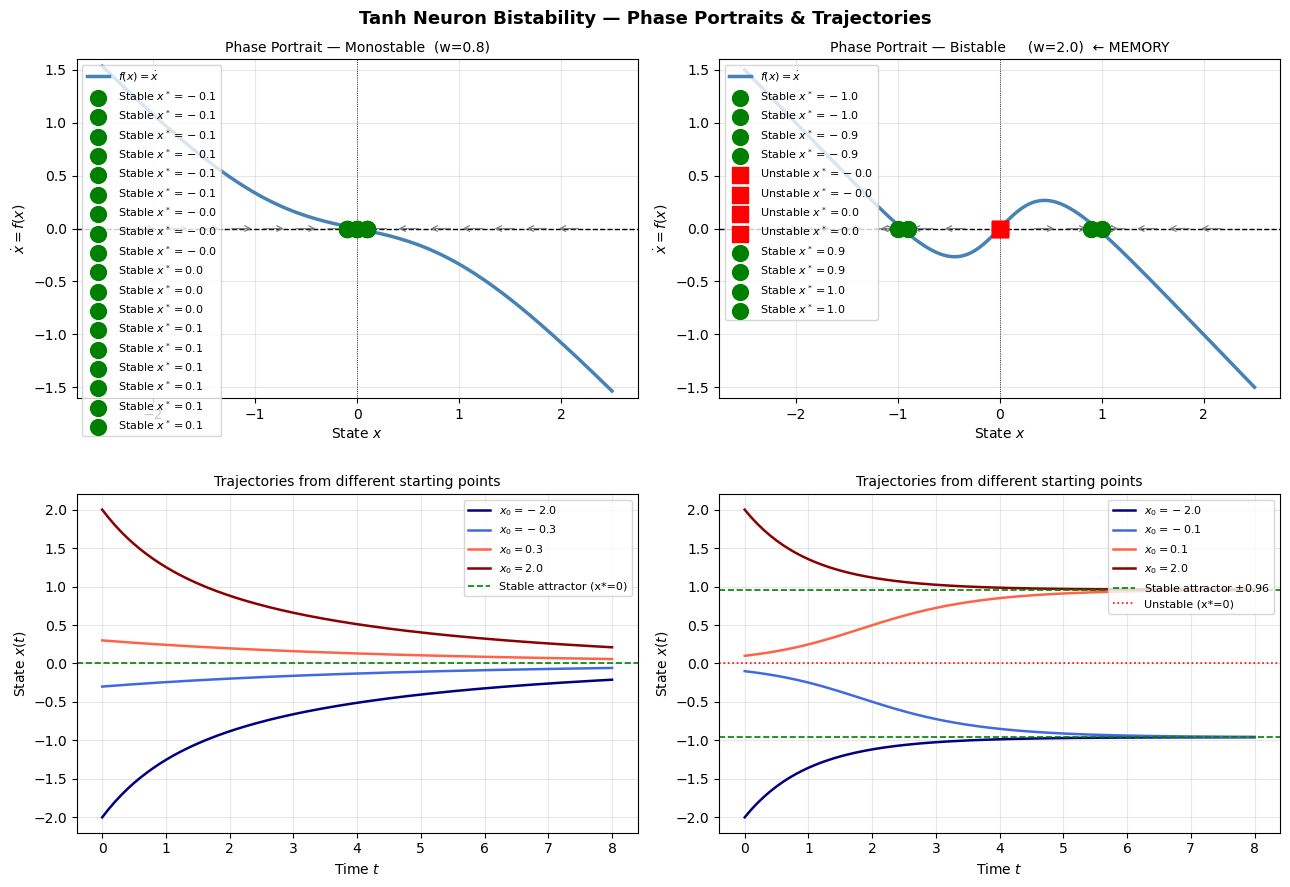

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────────────────
# Tanh Bistability: Phase Portrait & Trajectories
#
# Model:  dx/dt = f(x) = -x + tanh(w*x)
#
# We compare two regimes:
#   w = 0.8  → monostable  (only x*=0 is a fixed point)
#   w = 2.0  → bistable    (x*=0 unstable; ±x* stable)
# ─────────────────────────────────────────────────────────────────────────────

def f(x, w):
    """Flow function for the tanh neuron: dx/dt = -x + tanh(w*x)."""
    return -x + np.tanh(w * x)

def euler_solve(w, x0, dt=0.05, T=8):
    """Integrate the ODE with the Euler method and return the trajectory."""
    steps = int(T / dt)
    traj  = [x0]
    x     = x0
    for _ in range(steps):
        x = x + f(x, w) * dt   # Euler step: x_new = x_old + f(x) * dt
        traj.append(x)
    return np.array(traj)

# ── Build the grid for phase portraits ───────────────────────────────────────
x_vals = np.linspace(-2.5, 2.5, 300)
w_mono = 0.8   # monostable regime
w_bi   = 2.0   # bistable regime

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Tanh Neuron Bistability — Phase Portraits & Trajectories', fontsize=13, fontweight='bold')

for col, (w, title) in enumerate([(w_mono, f'Monostable  (w={w_mono})'),
                                   (w_bi,   f'Bistable     (w={w_bi})  ← MEMORY')]):

    # ── TOP ROW: Phase portrait  (x vs dx/dt) ────────────────────────────────
    ax_phase = axes[0][col]
    y_flow   = f(x_vals, w)

    ax_phase.plot(x_vals, y_flow, 'steelblue', lw=2.5, label='$f(x)=\dot{x}$')
    ax_phase.axhline(0, color='k', lw=1.0, ls='--')   # the x-axis = zero flow
    ax_phase.axvline(0, color='k', lw=0.6, ls=':')

    # Mark fixed points
    fps = [x for x in x_vals if abs(f(x, w)) < 0.03]      # rough zero-crossings
    # Characterise each: stable if f'(x*)<0, unstable if f'(x*)>0
    dx  = x_vals[1] - x_vals[0]
    df  = np.gradient(y_flow, dx)
    for x0 in np.round(fps, 1):
        idx  = np.argmin(np.abs(x_vals - x0))
        stab = df[idx] < 0
        mk   = 'o' if stab else 's'
        clr  = 'green' if stab else 'red'
        lbl  = f'Stable $x^*={x0:.1f}$' if stab else f'Unstable $x^*={x0:.1f}$'
        ax_phase.scatter([x0], [0], marker=mk, s=130, color=clr, zorder=6, label=lbl)

    # Arrow quivers to show direction of flow
    for xq in np.linspace(-2.2, 2.2, 15):
        vel = f(xq, w)
        ax_phase.annotate('', xy=(xq + 0.25*np.sign(vel), 0),
                          xytext=(xq, 0),
                          arrowprops=dict(arrowstyle='->', color='gray', lw=0.9))

    ax_phase.set_xlabel('State $x$', fontsize=10)
    ax_phase.set_ylabel('$\\dot{x} = f(x)$', fontsize=10)
    ax_phase.set_title(f'Phase Portrait — {title}', fontsize=10)
    ax_phase.legend(fontsize=8, loc='upper left')
    ax_phase.grid(alpha=0.3)
    ax_phase.set_ylim(-1.6, 1.6)

    # ── BOTTOM ROW: Time trajectories ─────────────────────────────────────────
    ax_traj = axes[1][col]
    T       = 8
    t_axis  = np.linspace(0, T, int(T/0.05)+1)
    starts  = [-2.0, -0.1, 0.1, 2.0] if w > 1 else [-2.0, -0.3, 0.3, 2.0]
    traj_colors = ['navy', 'royalblue', 'tomato', 'darkred']

    for x0, c in zip(starts, traj_colors):
        traj = euler_solve(w, x0)
        ax_traj.plot(t_axis, traj, color=c, lw=1.8, label=f'$x_0={x0}$')

    # Draw attractor lines
    if w > 1:
        import scipy.optimize
        x_star = scipy.optimize.brentq(lambda x: f(x, w), 0.5, 2.5)
        ax_traj.axhline( x_star, color='green', ls='--', lw=1.2, label=f'Stable attractor $\\pm{x_star:.2f}$')
        ax_traj.axhline(-x_star, color='green', ls='--', lw=1.2)
        ax_traj.axhline(0,       color='red',   ls=':',  lw=1.2, label='Unstable (x*=0)')
    else:
        ax_traj.axhline(0, color='green', ls='--', lw=1.2, label='Stable attractor (x*=0)')

    ax_traj.set_xlabel('Time $t$', fontsize=10)
    ax_traj.set_ylabel('State $x(t)$', fontsize=10)
    ax_traj.set_title('Trajectories from different starting points', fontsize=10)
    ax_traj.legend(fontsize=8, loc='upper right')
    ax_traj.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## How to Read the Tanh Graph

### Top Row — Phase Portrait (`x` vs `ẋ`)

The blue curve is the **velocity map**: its y-value tells you *how fast* and *which direction* the state is moving at every x.

| Feature | What it means |
|---|---|
| Curve crosses zero (zero-crossing) | **Fixed point** — the state is not moving |
| Curve **above** the x-axis (ẋ > 0) | State moves **right** (x is increasing) |
| Curve **below** the x-axis (ẋ < 0) | State moves **left** (x is decreasing) |
| Crossing goes **positive→negative** | **STABLE** fixed point (arrows point inward) |
| Crossing goes **negative→positive** | **UNSTABLE** fixed point (arrows point outward) |

**Monostable (w=0.8):** Only one zero-crossing at x=0. Arrows point toward it from both sides → it is a stable attractor. Every starting state ends up at zero.

**Bistable (w=2.0):** Three zero-crossings. The centre one at x=0 is unstable (arrows diverge). The outer two (≈±1.3) are stable (arrows converge). The system has **two possible memory states**.

### Bottom Row — Trajectories over Time

- Each coloured line is one simulated particle starting at a different `x₀`.
- **Monostable:** All lines converge to zero regardless of starting point.
- **Bistable:** Lines starting left of zero converge to ~−1.3; lines starting right converge to ~+1.3. The system **locks in** a binary state.

### Takeaway

> The bistable regime models how a **recurrent neuron becomes a 1-bit memory cell**. Once driven positive (by an input), it stays positive indefinitely — even after the input is removed. This is the dynamical-systems explanation for **why LSTM/GRU gates work**: they create bistable units that hold information across long sequences. The system's "choice" of +1.3 vs −1.3 is the binary decision.

The weight `w` is the **bifurcation parameter**: below `w=1` the system has no memory; above it, memory emerges spontaneously. This phase transition is studied in the theory of *bifurcations* (covered in Chapter 3).

---

## B. State-Space Models & Eigenvalue Placement (Mamba / S4)

### The Model

A linear State-Space Model (SSM) has the form:

$$\dot{\mathbf{x}} = A \mathbf{x} + B u$$

For the **stability** analysis we focus on the homogeneous part $\dot{\mathbf{x}} = A\mathbf{x}$.  
The solution is $\mathbf{x}(t) = e^{At}\mathbf{x}(0)$, and behaviour is governed entirely by the **eigenvalues $\lambda_i$ of $A$**.

### Eigenvalue → Stability Rule

Each eigenvalue $\lambda = \alpha + i\beta$ contributes a mode $e^{\lambda t} = e^{\alpha t}(\cos\beta t + i\sin\beta t)$:

| Real part $\alpha = \text{Re}(\lambda)$ | Imaginary part $\beta = \text{Im}(\lambda)$ | Behaviour |
|---|---|---|
| $< 0$ | 0 | Exponential **decay** — stable, no oscillation |
| $< 0$ | $\neq 0$ | **Damped oscillation** — spirals to zero |
| $= 0$ | $\neq 0$ | **Persistent oscillation** — perfect memory |
| $> 0$ | any | **Exponential growth** — unstable, exploding gradients |

### Causal Link

S4 / Mamba engineer the matrix $A$ (using the **HiPPO** construction) so all eigenvalues lie in the **stable half-plane** ($\text{Re}(\lambda) \leq 0$), while rich imaginary parts let the model represent long-range oscillatory patterns. This is precisely a **stability-via-eigenvalue-placement** problem solved with dynamical-systems theory.

C:\Users\nisar\AppData\Local\Temp\ipykernel_19004\615133891.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


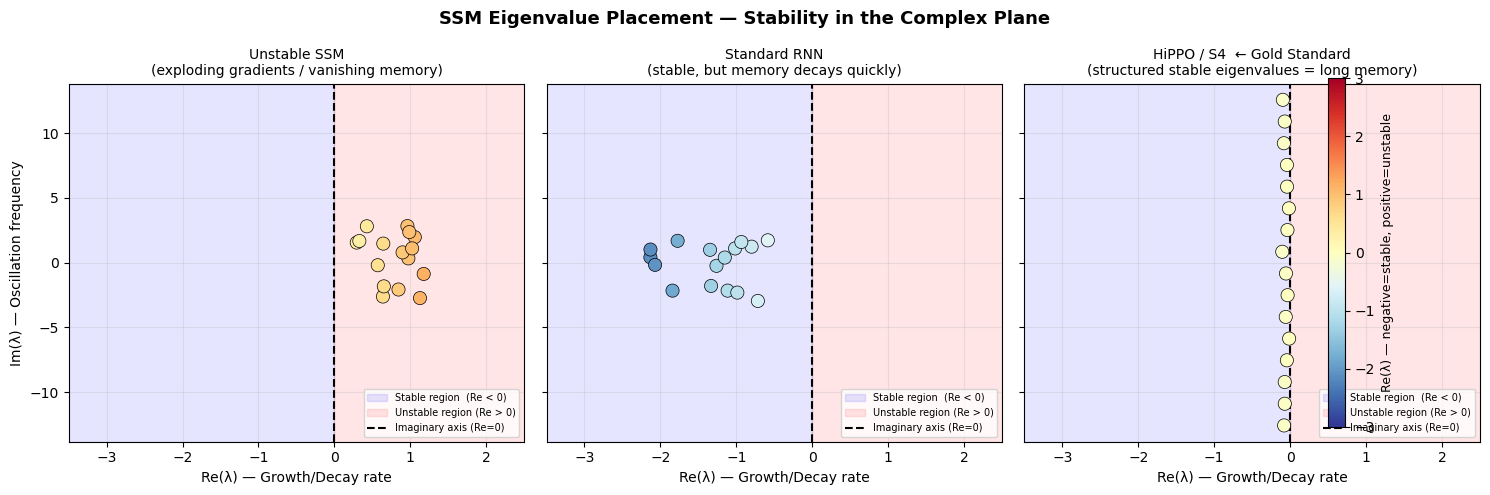

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ─────────────────────────────────────────────────────────────────────────────
# SSM Eigenvalue Visualisation
#
# We create three representative sets of eigenvalues:
#   (1) Unstable SSM  — eigenvalues in right half-plane  (exploding gradients)
#   (2) Stable SSM    — eigenvalues in left half-plane   (standard RNN)
#   (3) HiPPO / S4   — eigenvalues on / near imaginary axis (lossless memory)
#
# The COLOUR of each dot encodes how quickly that mode decays:
#   Red  = fast decay | Blue = slow decay / persistent
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(42)

# -- (1) Unstable eigenvalues (some Re > 0) ----------------------------------
n = 16
eigs_unstable = (rng.uniform(0.2, 1.2, n) +
                 1j * rng.uniform(-3, 3, n))

# -- (2) Standard stable RNN  (Re << 0) --------------------------------------
eigs_stable = (-rng.uniform(0.3, 2.5, n) +
               1j * rng.uniform(-3, 3, n))

# -- (3) HiPPO / S4-style  (Re ≈ 0, rich Im spectrum) ----------------------
eigs_hippo = (-rng.uniform(0.01, 0.12, n) +              # tiny negative real part
              1j * np.linspace(-np.pi*n/4, np.pi*n/4, n)) # evenly spaced imaginary

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('SSM Eigenvalue Placement — Stability in the Complex Plane',
             fontsize=13, fontweight='bold')

configs = [
    (eigs_unstable, 'Unstable SSM\n(exploding gradients / vanishing memory)',  'tomato'),
    (eigs_stable,   'Standard RNN\n(stable, but memory decays quickly)',        'royalblue'),
    (eigs_hippo,    'HiPPO / S4  ← Gold Standard\n(structured stable eigenvalues = long memory)', 'seagreen'),
]

for ax, (eigs, title, colour) in zip(axes, configs):
    re = eigs.real
    im = eigs.imag

    # Shade the stable / unstable half-planes
    ax.axvspan(-5, 0,   alpha=0.10, color='blue',  label='Stable region  (Re < 0)')
    ax.axvspan( 0,  5,  alpha=0.10, color='red',   label='Unstable region (Re > 0)')
    ax.axvline(0, color='k', lw=1.5, ls='--', label='Imaginary axis (Re=0)')

    # Colour each dot by its decay rate (real part)
    sc = ax.scatter(re, im, c=re, cmap='RdYlBu_r', vmin=-3, vmax=3,
                    s=90, zorder=5, edgecolors='k', linewidths=0.5)

    ax.set_xlabel('Re(λ) — Growth/Decay rate', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('Im(λ) — Oscillation frequency', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-3.5, 2.5)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc='lower right')

# Shared colorbar
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Re(λ) — negative=stable, positive=unstable', fontsize=9)

plt.tight_layout()
plt.show()

##  How to Read the Eigenvalue Plot

The **complex plane** has a crucial structure:

```
           Im(λ)
            ↑
  STABLE    |    UNSTABLE
  Re(λ)<0  |    Re(λ)>0
  memory    |    exploding
  decays    |    gradients
  ──────────┼──────────────→  Re(λ)
            |
  Im(λ)≠0 → oscillatory modes (frequencies inside the memory)
```

### Reading each panel:

**Panel 1 — Unstable SSM:** Eigenvalues on the right half-plane. Any mode with $\text{Re}(\lambda) > 0$ grows exponentially →the hidden state **blows up**. This is the classic **exploding-gradient** problem in vanilla RNNs trained on long sequences.

**Panel 2 — Standard stable RNN:** All eigenvalues are in the left half-plane, so the system is stable. But because $|\text{Re}(\lambda)|$ is large, the modes **decay quickly** → **vanishing gradients** over long time horizons. The network forgets its past.

**Panel 3 — HiPPO / S4:** Eigenvalues are *clustered near the imaginary axis* with tiny negative real parts. Each mode decays very slowly (nearly lossless memory) while the rich imaginary parts give the model a **broad frequency spectrum** — it can remember patterns at many timescales simultaneously. This is the engineering insight behind S4 and Mamba.

### Takeaway

> Training a sequence model is, at its core, an **eigenvalue-placement problem**. The HiPPO matrix is not learned by gradient descent — it is **analytically designed** from optimal polynomial-projection theory so that eigenvalues land in exactly the right location in the complex plane. Dynamical-systems theory tells us *where* to aim; linear algebra tells us *how* to construct the matrix. This is one of the clearest examples of physics-informed deep learning architecture design.

---

# The Grand Bridge: Physics, Stability & AI

All three examples above are instances of the **same mathematical principle**:

> *A system evolves by sliding downhill on an energy landscape. Stable equilibria are valleys. Training finds valleys. Memory is stored in valleys.*

## The Lyapunov Stability Perspective

A function $V(x) \geq 0$ with $\dot{V} \leq 0$ along every trajectory is called a **Lyapunov function**. Its existence guarantees stability without solving the ODE exactly.

| System | Lyapunov Function $V$ | Guaranteed property |
|---|---|---|
| Gradient descent | $\mathcal{L}(\theta)$ (loss) | Loss converges to a fixed point |
| Tanh neuron | $V(x) = x^2/2 - \int \tanh(wx)\,dx$ | State locks to bistable attractor |
| SSM (stable) | $V(x) = x^T P x$ (quadratic, $P > 0$) | Hidden state decays / converges |

## Conservative vs. Dissipative

| Feature | Conservative (e.g., pendulum in vacuum) | Dissipative (e.g., pendulum in honey) | Deep Learning |
|---|---|---|---|
| Energy over time | **Constant** | **Strictly decreasing** | **Strictly decreasing** |
| Trajectories | Closed orbits (cycles) | Spirals into fixed point | Converges to loss minimum |
| Memory | Perpetual oscillation | Settles | Settles = generalisation |
| Bridge | Classical mechanics | Statistical mechanics / friction | Optimisation theory |

## Why This Matters for the Future of AI

1. **Stability = Reliability.** A system whose eigenvalues lie in the stable half-plane cannot blow up. AI safety researchers use Lyapunov theory to prove that neural controllers will not destabilise a robotics system.

2. **Memory = Attractors.** Long-term memory in LLMs and SSMs comes from carefully placed attractors in the state space — bistable units, stable eigenvalues, learned embedding clusters.

3. **Training = Dissipation.** Gradient descent works because the loss landscape admits a Lyapunov function (the loss itself). The learning rate is the "friction coefficient" — too large and the particle bounces over valleys; too small and it moves infinitesimally slowly.

4. **Bifurcation = Phase Transition.** When you change a hyperparameter (weight magnitude, learning rate, sequence length), the system can undergo a qualitative change — monostable → bistable, stable → unstable. These are the phase transitions studied in theoretical deep learning.

> **Summary:** The mathematics that Strogatz uses to describe particles sliding downhill in goo is *identical* to the mathematics of gradient descent, recurrent memory, and SSM design. Learning dynamical systems is learning the physics of AI.